In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



sns.set_style(style="whitegrid")
%matplotlib inline

In [2]:
titanic =  sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# Advance Charts in Matplotlib

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


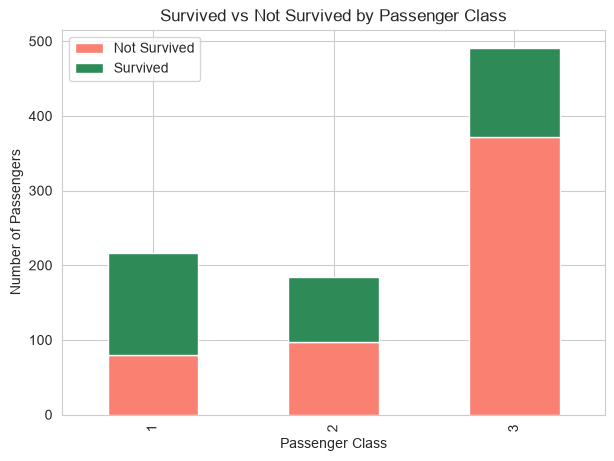

In [5]:
# Group data: count of survived (0/1) for each passenger class
stacked_data = titanic.groupby(['pclass', 'survived']).size().unstack()
print(stacked_data)

# Plot stacked bar chart
stacked_data.plot(kind='bar', stacked=True, color=['salmon', 'seagreen'], figsize=(7,5))
plt.title("Survived vs Not Survived by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Not Survived", "Survived"])
plt.show()

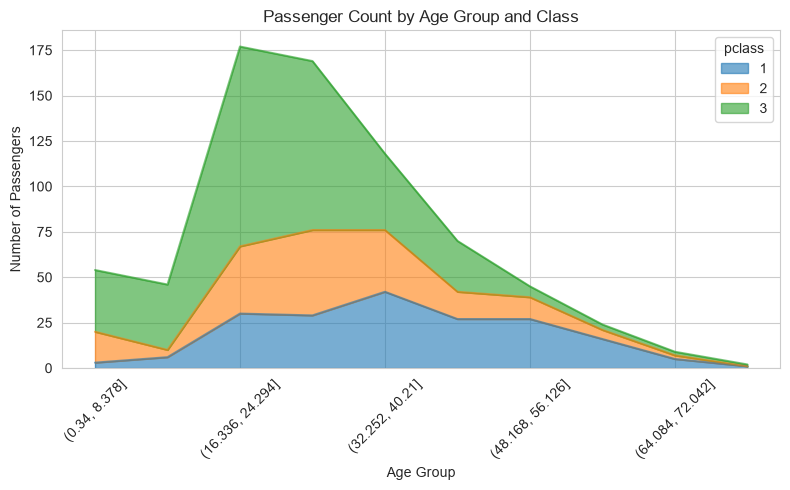

In [6]:
# Create age groups (bins)
age_bins = pd.cut(titanic['age'].dropna(), bins=10)

# Count passengers in each age group, split by class
area_data = titanic.dropna(subset=['age']).groupby([age_bins, 'pclass']).size().unstack()
area_data.index = area_data.index.astype(str)   # convert bin labels to string for plotting

# Plot area chart
area_data.plot(kind='area', stacked=True, alpha=0.6, figsize=(8,5))
plt.title("Passenger Count by Age Group and Class")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

             mean        std
pclass                      
1       84.154687  78.380373
2       20.662183  13.417399
3       13.675550  11.778142


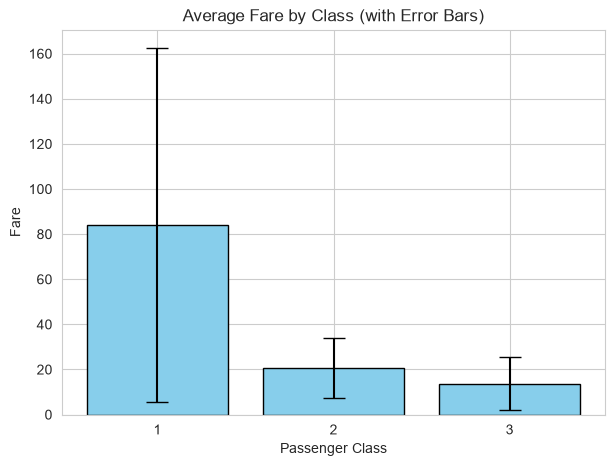

In [7]:
# Calculate mean and standard deviation of fare, per class
fare_stats = titanic.groupby('pclass')['fare'].agg(['mean', 'std'])
print(fare_stats)

# Plot bar chart with error bars
plt.figure(figsize=(7,5))
plt.bar(fare_stats.index.astype(str), fare_stats['mean'],
        yerr=fare_stats['std'], capsize=8, color='skyblue', edgecolor='black')
plt.title("Average Fare by Class (with Error Bars)")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

In [8]:
np.random.seed(42)

months = pd.date_range(
    start='2024-01-01',
    periods=12,
    freq='MS'
).strftime('%b')

sales_A = np.random.randint(50, 150, 12)
sales_B = np.random.randint(40, 130, 12)
sales_C = np.random.randint(30, 100, 12)

monthly_df = pd.DataFrame({
    'Month': months,
    'Product A': sales_A,
    'Product B': sales_B,
    'Product C': sales_C
})

monthly_df

,Month,Product A,Product B,Product C
0,Jan,101,63,62
1,Feb,142,42,87
2,Mar,64,61,51
3,Apr,121,92,78
4,May,110,41,88
5,Jun,70,127,71
6,Jul,132,69,89
7,Aug,136,77,44
8,Sep,124,41,91
9,Oct,124,103,91


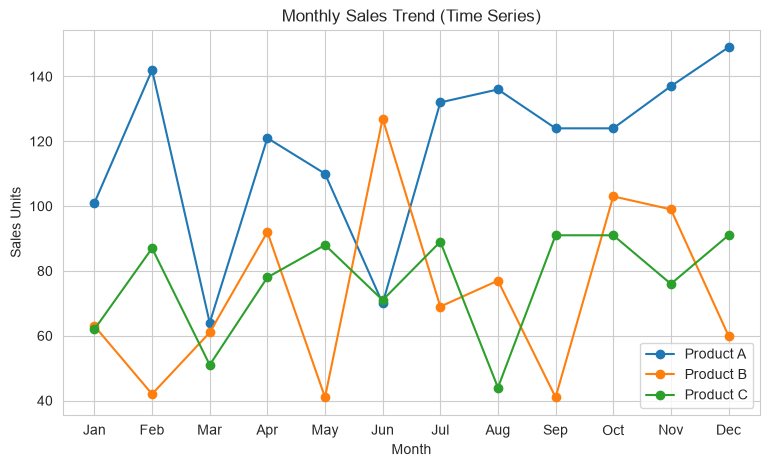

In [9]:
# Simple time series line chart
plt.figure(figsize=(9,5))
plt.plot(monthly_df['Month'], monthly_df['Product A'], marker='o', label='Product A')
plt.plot(monthly_df['Month'], monthly_df['Product B'], marker='o', label='Product B')
plt.plot(monthly_df['Month'], monthly_df['Product C'], marker='o', label='Product C')
plt.title("Monthly Sales Trend (Time Series)")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend()
plt.show()

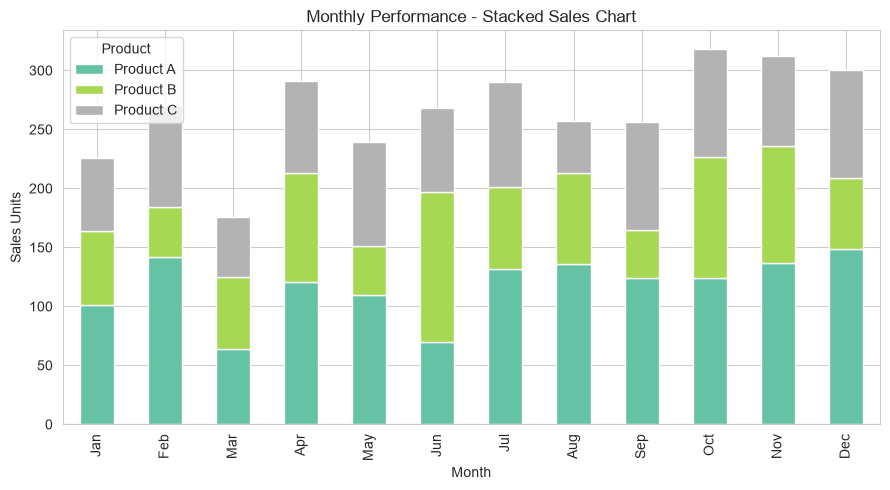

In [10]:
# Stacked bar chart across months
monthly_df.set_index('Month')[['Product A', 'Product B', 'Product C']].plot(
    kind='bar', stacked=True, figsize=(9,5), colormap='Set2')
plt.title("Monthly Performance - Stacked Sales Chart")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend(title="Product")
plt.tight_layout()
plt.show()

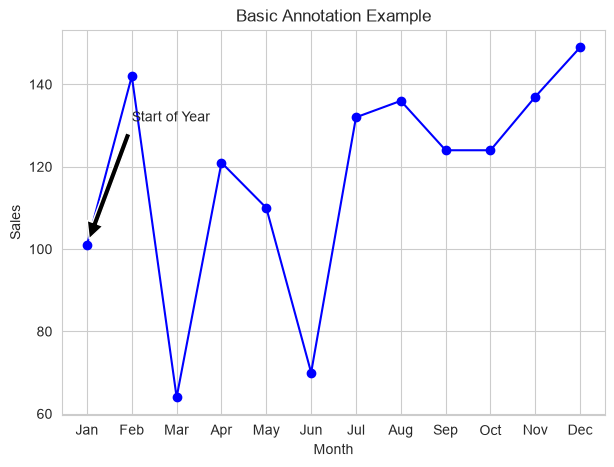

In [11]:
plt.figure(figsize=(7,5))
plt.plot(monthly_df['Month'], monthly_df['Product A'], marker='o', color='blue')

# Annotate a single point
plt.annotate('Start of Year', xy=(monthly_df['Month'][0], monthly_df['Product A'][0]),
             xytext=(1, monthly_df['Product A'][0] + 30),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Basic Annotation Example")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

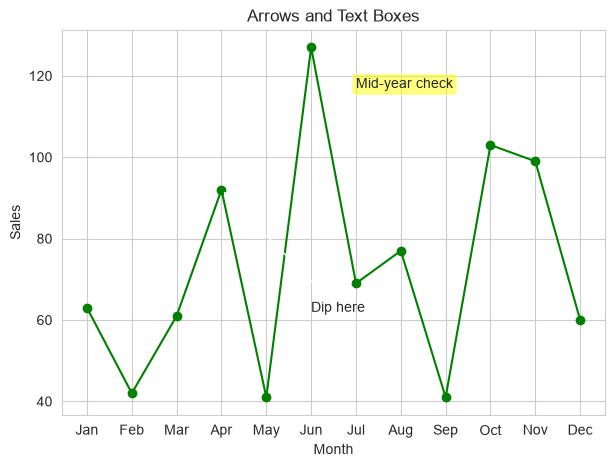

In [12]:
plt.figure(figsize=(7,5))
plt.plot(monthly_df['Month'], monthly_df['Product B'], marker='o', color='green')

# Text box using bbox
plt.text(6, monthly_df['Product B'].max() - 10, "Mid-year check",
         fontsize=10, bbox=dict(facecolor='yellow', alpha=0.5, boxstyle='round'))

# Arrow using annotate
plt.annotate('Dip here', xy=(3, monthly_df['Product B'][3]),
             xytext=(5, monthly_df['Product B'][3] - 30),
             arrowprops=dict(facecolor='red', arrowstyle='->'))

plt.title("Arrows and Text Boxes")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

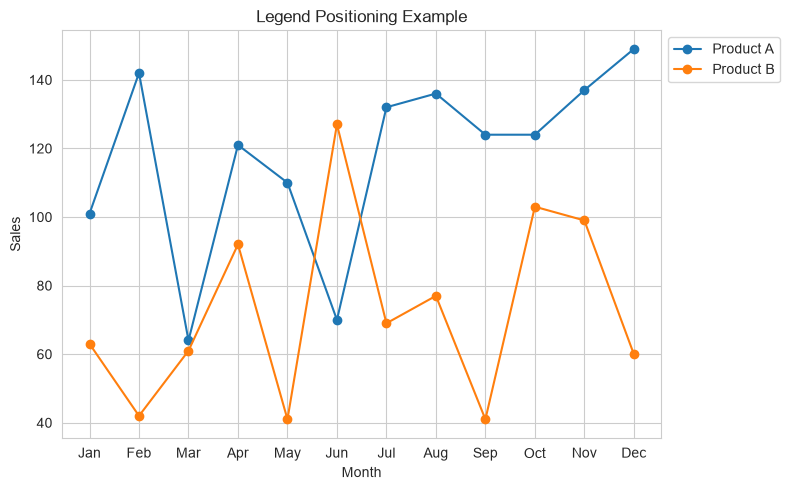

In [13]:
plt.figure(figsize=(8,5))
plt.plot(monthly_df['Month'], monthly_df['Product A'], marker='o', label='Product A')
plt.plot(monthly_df['Month'], monthly_df['Product B'], marker='o', label='Product B')

# Try different legend locations: 'upper left', 'lower right', 'best', etc.
plt.legend(loc='best', bbox_to_anchor=(1.0, 1.0))  # legend outside the plot
plt.title("Legend Positioning Example")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

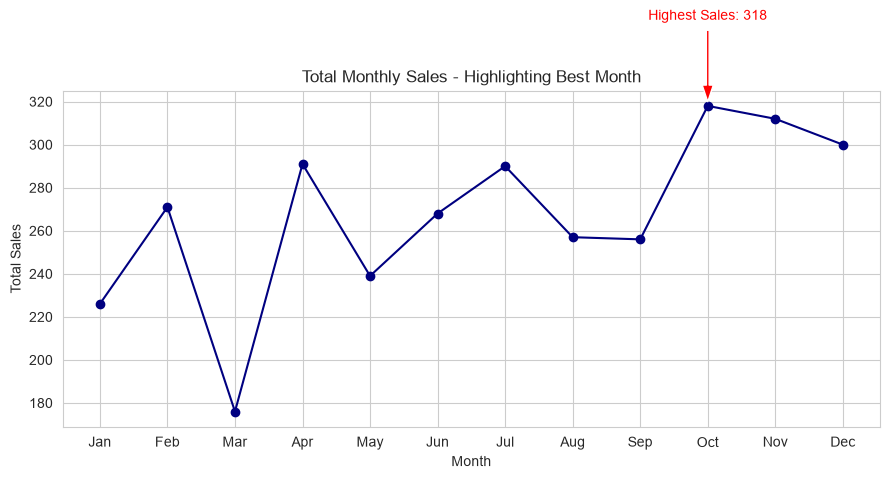

In [14]:
# Calculate total sales per month
monthly_df['Total'] = monthly_df['Product A'] + monthly_df['Product B'] + monthly_df['Product C']

# Find the month with highest total sales
max_idx = monthly_df['Total'].idxmax()
max_month = monthly_df.loc[max_idx, 'Month']
max_val = monthly_df.loc[max_idx, 'Total']

plt.figure(figsize=(9,5))
plt.plot(monthly_df['Month'], monthly_df['Total'], marker='o', color='navy')

# Highlight the highest point with an arrow and label
plt.annotate(f'Highest Sales: {max_val}',
             xy=(max_month, max_val),
             xytext=(max_idx, max_val + 40),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=10, color='red', ha='center')

plt.title("Total Monthly Sales - Highlighting Best Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

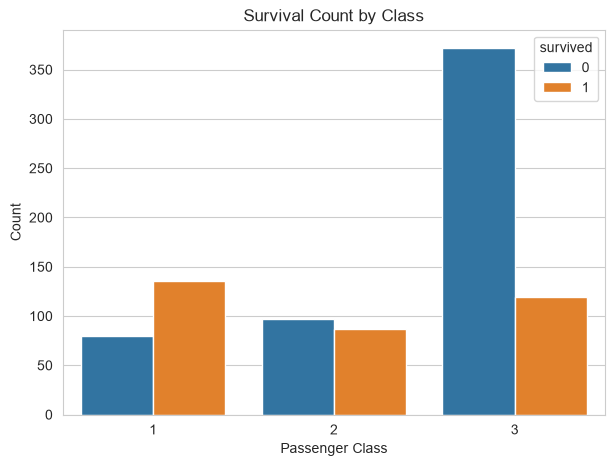

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=titanic, x='pclass', hue='survived')
plt.title("Survival Count by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

# Save the chart as a PNG file
plt.savefig("chart_survival.png")
plt.show()

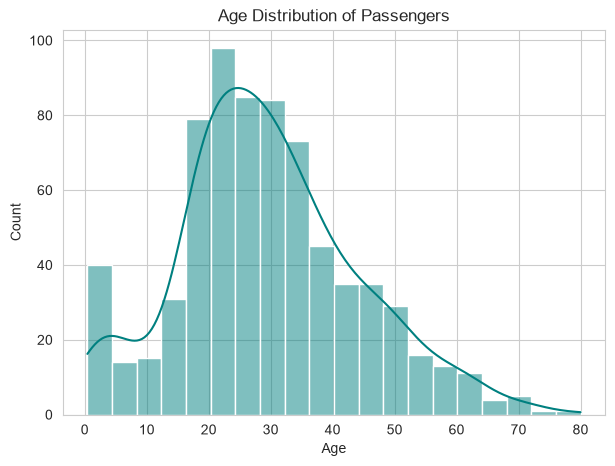

Chart saved as PNG, SVG and PDF


In [16]:
plt.figure(figsize=(7,5))
sns.histplot(data=titanic, x='age', kde=True, color='teal')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")

# Save in multiple formats with higher DPI
plt.savefig("age_distribution.png", dpi=300)   # high resolution PNG
plt.savefig("age_distribution.svg")            # vector format
plt.savefig("age_distribution.pdf")            # PDF format
plt.show()

print("Chart saved as PNG, SVG and PDF")

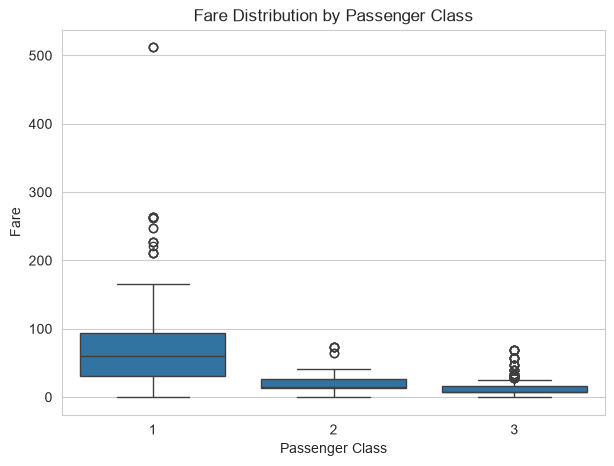

Chart exported as fare_by_class.pdf


In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(data=titanic, x='pclass', y='fare')
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

# Export the final chart as a PDF file
plt.savefig("fare_by_class.pdf", dpi=300)
plt.show()

print("Chart exported as fare_by_class.pdf")